# **04_Exploratory_Data_Analysis**

This notebook performs **Exploratory Data Analysis (EDA)** on the 66,878 cleaned reviews from `combined_reviews_clean.csv`. It analyzes user sentiment and platform behavior across Grab, Gojek, Maxim, and InDrive through six key analyses: average rating and NPS proxy score, stacked rating distribution, monthly rating trends over time, top keywords extracted from review text, pain points vs. praise keyword breakdown by sentiment, developer reply rate and response time, and a keyword-based churn risk signal. The output is a series of visualizations saved to `reports/figures/`, providing actionable insights into how each platform performs in the eyes of its users.

## **1. Import Library**

Importing all necessary libraries and defining key constants. pandas and numpy handle data manipulation, while re is used for regex-based text processing. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import re, warnings

## **2. Environment Setup & Configuration**

This cell iterates over each platform name, constructs the expected file path, and loads the CSV if it exists. A `platform` column is added to each individual DataFrame to preserve the source label. All four platform DataFrames are then concatenated into a single unified DataFrame `df_raw`. The total row count is printed as a sanity check.


In [ ]:
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = {"grab": "#00B14F", "gojek": "#00AED6", "maxim": "#FF6900", "indrive": "#3B2D8E"}
PLATFORMS = ["grab", "gojek", "maxim", "indrive"]

CLEAN_DIR = Path("../data/clean")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


Loaded 66,878 rows
platform
gojek      18301
indrive    17979
grab       16218
maxim      14380
Name: count, dtype: int64


## **3. Load Dataset**

This cell loads the cleaned CSV file (`combined_reviews_clean.csv`) produced by the data cleaning notebook. The `at` column is parsed directly as a datetime type for time-based analysis. Three safety fallbacks are included in case the notebook is run standalone (i.e., without running the cleaning notebook first): `content_normalized` is reconstructed from raw `content` if missing; `has_reply` is re-derived from the reply column if absent; and `churn_signal` is initialized to 0 if not yet computed. A row count and per-platform distribution are printed to confirm the data loaded correctly — 66,878 total rows across four platforms.

In [ ]:
df = pd.read_csv(CLEAN_DIR / "combined_reviews_clean.csv", parse_dates=["at"])
# Ensure normalized column exists (fallback if running standalone)
if "content_normalized" not in df.columns:
    df["content_normalized"] = df["content"].fillna("").str.lower()
if "has_reply" not in df.columns:
    df["has_reply"] = df["replyContent"].notna().astype(int)
if "churn_signal" not in df.columns:
    df["churn_signal"] = 0

print(f"Loaded {len(df):,} rows")
print(df["platform"].value_counts())

## **4. Average Rating & NPS Proxy per Platform**

This cell produces a side-by-side horizontal bar chart comparing two key satisfaction metrics across platforms. **Left chart** shows the mean star rating per platform (scale 1–5). Maxim leads with the highest average, while Gojek scores lowest. **Right chart** shows an NPS Proxy Score, calculated as: (% of 5-star reviews) minus (% of 1–2 star reviews), multiplied by 100. This is an approximation of the Net Promoter Score using star ratings as a proxy for promoters and detractors. Bars are colored green for positive NPS and red for negative. Value labels are annotated directly on each bar. The chart is saved as `04_rating_nps.png`.

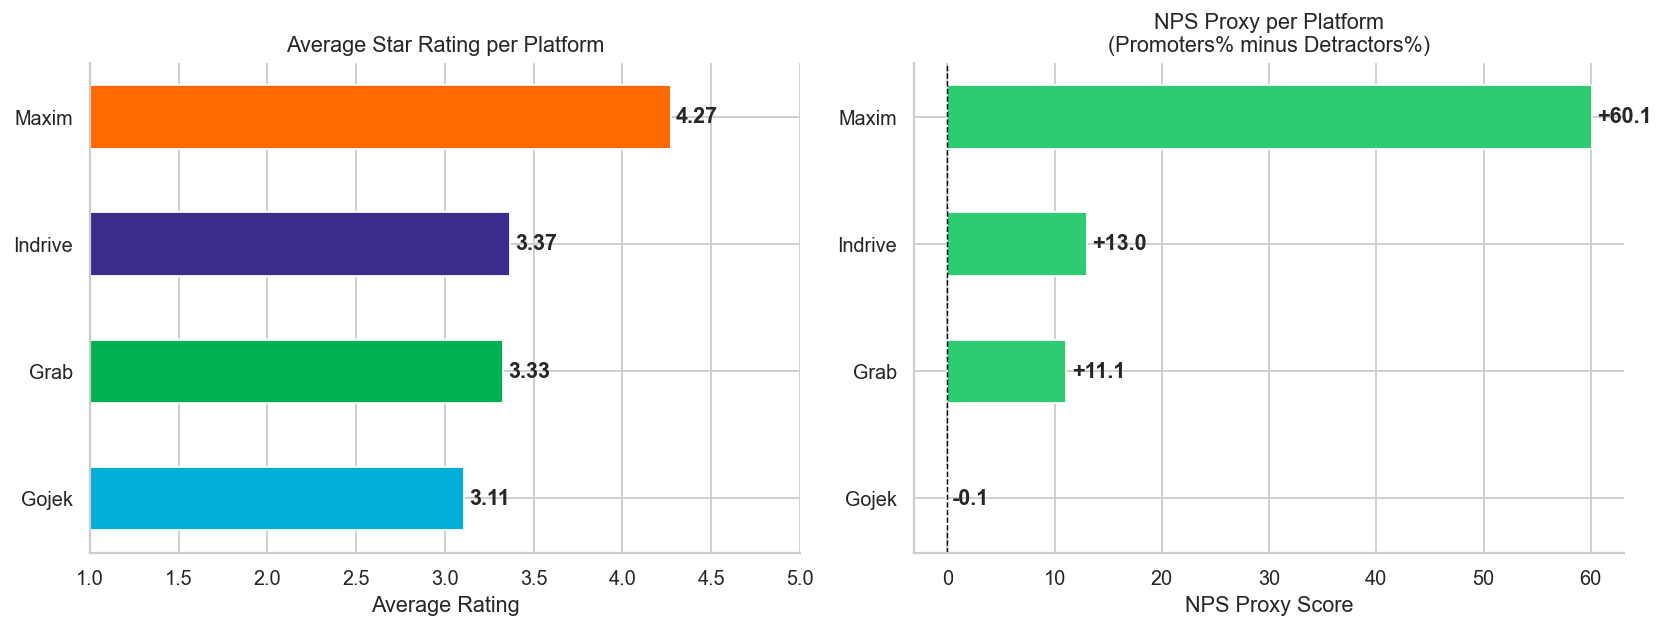

In [51]:
avg_scores = df.groupby("platform")["score"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].barh(
    [p.capitalize() for p in avg_scores.index],
    avg_scores.values,
    color=[PALETTE[p.lower()] for p in avg_scores.index],
    edgecolor="white", height=0.5
)
axes[0].set_xlim(1, 5)
axes[0].set_xlabel("Average Rating")
axes[0].set_title("Average Star Rating per Platform")
for bar, val in zip(bars, avg_scores.values):
    axes[0].text(val + 0.03, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", va="center", fontweight="bold")

def nps_proxy(series):
    promoters = (series == 5).sum()
    detractors = (series <= 2).sum()
    n = len(series)
    return round((promoters - detractors) / n * 100, 1)

nps = df.groupby("platform")["score"].apply(nps_proxy).sort_values()
colors_nps = ["#E74C3C" if v < 0 else "#2ECC71" for v in nps.values]
axes[1].barh([p.capitalize() for p in nps.index], nps.values,
             color=colors_nps, edgecolor="white", height=0.5)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("NPS Proxy Score")
axes[1].set_title("NPS Proxy per Platform\n(Promoters% minus Detractors%)")
for i, (p, val) in enumerate(zip(nps.index, nps.values)):
    axes[1].text(val + 0.5, i, f"{val:+.1f}", va="center", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_rating_nps.png", bbox_inches="tight")
plt.show()


> * **Maxim is the clear market leader in user satisfaction**, dominating both charts with the highest **Average Star Rating (4.27)** and an exceptionally strong **NPS Proxy score (+60.1)**.
> * **Indrive and Grab show moderate, highly comparable performance**, maintaining similar satisfaction levels with average ratings around **3.33–3.37** and positive NPS scores between **+11.1 and +13.0**.
> * **Gojek struggles significantly compared to its competitors**, landing at the bottom with the lowest **Average Star Rating (3.11)** and a **negative NPS Proxy score (-0.1)**, indicating it has more detractors than promoters.

## **5. Stacked Rating Distribution per Platform**

This cell visualizes the full distribution of star ratings (1–5) for each platform as a 100% stacked bar chart. Each platform's bar is divided into five colored segments proportional to the share of reviews at each star level: red for 1-star (most negative) through dark green for 5-star (most positive). `score_dist` is computed by grouping on platform and score, unstacking the score levels as columns, then normalizing each row to percentages. This chart reveals not just average scores but the full shape of sentiment for example, whether a platform has a bimodal distribution (many 1s and 5s, few in between). Saved as `04_score_stacked.png`.

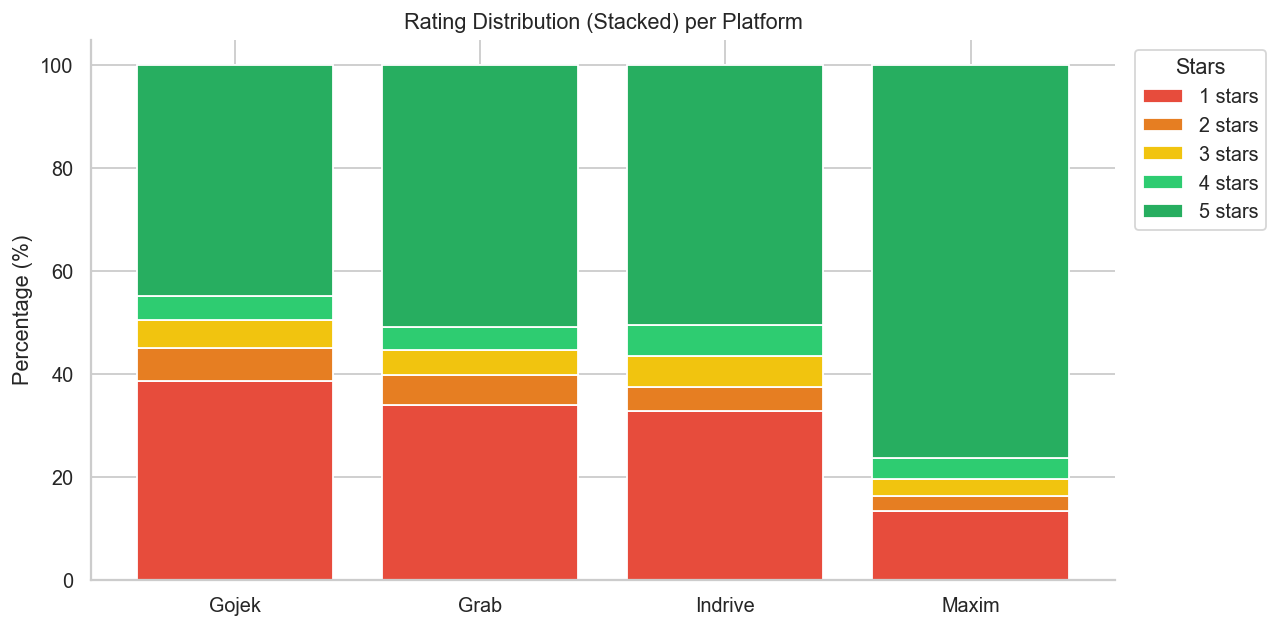

In [52]:
score_dist = (df.groupby(["platform", "score"])
               .size()
               .unstack(fill_value=0)
               .div(df.groupby("platform").size(), axis=0) * 100)

score_colors = {1:"#E74C3C", 2:"#E67E22", 3:"#F1C40F", 4:"#2ECC71", 5:"#27AE60"}

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(score_dist))
for star in [1, 2, 3, 4, 5]:
    if star not in score_dist.columns:
        continue
    vals = score_dist[star].values
    ax.bar(score_dist.index.str.capitalize(), vals,
           bottom=bottom, label=f"{star} stars",
           color=score_colors[star], edgecolor="white")
    bottom += vals

ax.set_ylabel("Percentage (%)")
ax.set_title("Rating Distribution (Stacked) per Platform")
ax.legend(title="Stars", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_score_stacked.png", bbox_inches="tight")
plt.show()


> * **Maxim heavily dominates in customer satisfaction**, with an overwhelming majority of its users giving it a **5-star rating** (reaching roughly **75%** of its total distribution).
> * **Gojek suffers from the highest user dissatisfaction**, capturing the largest share of **1-star ratings** at nearly **40%**, closely followed by Grab and Indrive which both hover around **33-35%** for 1-star reviews.
> * **Grab and Indrive share a nearly identical rating distribution profile**, showing a highly competitive baseline where both struggle with high negative reviews but maintain a decent **5-star segment of around 50%**.

## **6. Monthly Average Rating Trend (Line Chart)**

This cell plots a time-series line chart showing how each platform's average rating fluctuated month by month. It assumes a `monthly_avg` DataFrame was computed earlier (typically via a `pivot_table` or `groupby` on `year_month`). Each platform is drawn as a separate colored line with circular markers. A dashed horizontal reference line at rating = 3.0 is drawn to indicate the neutral midpoint. The y-axis is fixed between 1 and 5.2. This chart is useful for identifying seasonal dips, incidents (e.g., app updates gone wrong), or sustained improvement/decline trends over time.

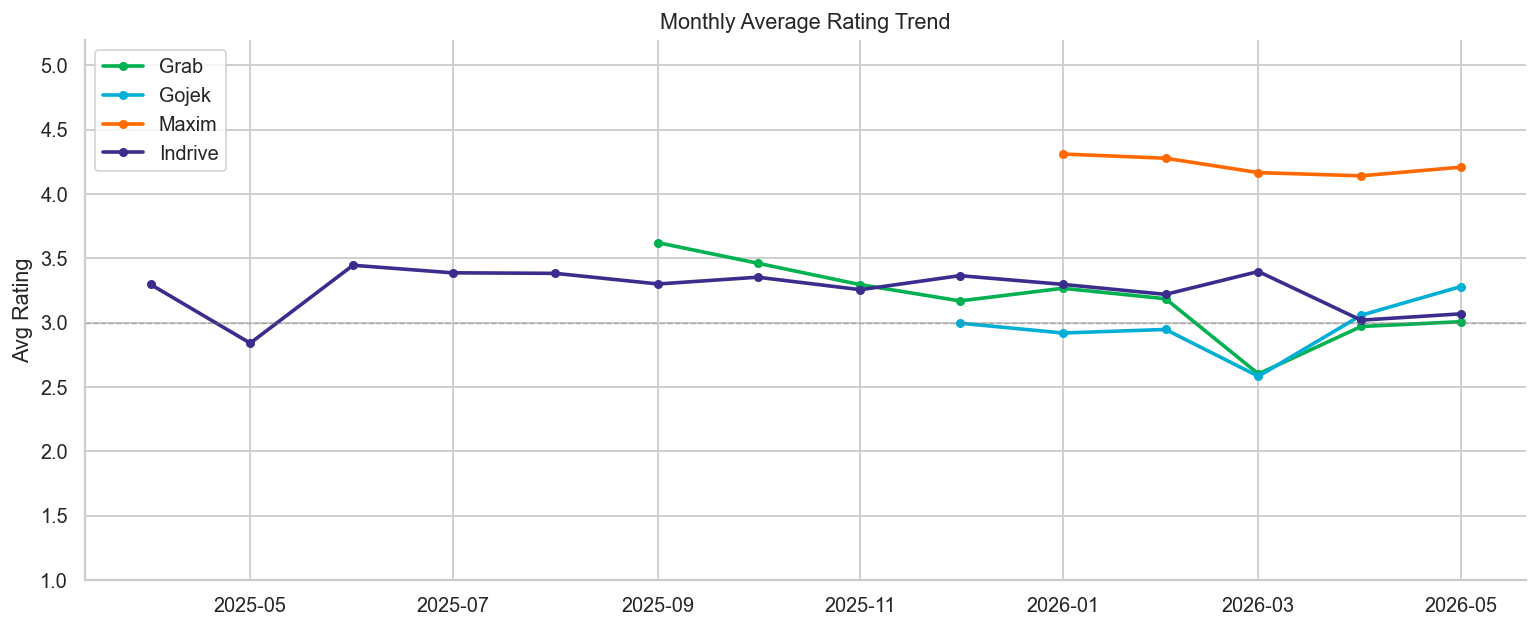

In [53]:
fig, ax = plt.subplots(figsize=(12, 5))

for p in PLATFORMS:
    # Ubah 'p' (misal: 'grab') menjadi 'Grab' agar cocok dengan kolom data
    p_col = p.capitalize()
    
    # Cek menggunakan p_col, bukan p
    if p_col in monthly_avg.columns:
        ax.plot(monthly_avg.index, monthly_avg[p_col], label=p_col,
                color=PALETTE[p], linewidth=2, marker="o", markersize=4)

ax.set_title("Monthly Average Rating Trend")
ax.set_ylabel("Avg Rating")
ax.set_ylim(1, 5.2)
ax.axhline(3, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

> * **Maxim consistently outperforms all competitors** by a wide margin, maintaining a highly stable and premium average rating **above 4.0** since its data tracking began in early 2026.
> * **Grab and Gojek experienced a major, synchronized drop in March 2026**, where both platforms plummeted to their lowest points at around a **2.6 average rating** before staging a recovery.
> * **Indrive shows the most long-term resilience and stability among the mid-tier apps**, hovering consistently around the **3.0 to 3.5 rating band** for over a year, completely avoiding the severe dips seen by Grab and Gojek.

## **7. Top Keywords per Platform (All Reviews)**

This cell defines the Indonesian stopword list and a reusable `top_keywords()` function, then applies it across all four platforms. The `ID_STOPWORDS` set covers common Indonesian filler words, particles, informal abbreviations (e.g., `gak`, `bgt`, `yg`), and pronouns that carry no topical meaning. `top_keywords()` tokenizes each review using a regex that extracts alphabetic words of 3+ characters, filters out stopwords, and returns the top N most frequent terms using `Counter`. The result is a 2×2 grid of horizontal bar charts — one per platform — showing the 15 most frequent words across all reviews. Defensive checks are included: if a platform's data is empty or no keywords are found, the subplot is hidden with a printed warning. This gives a high-level view of the most common topics users mention regardless of sentiment.

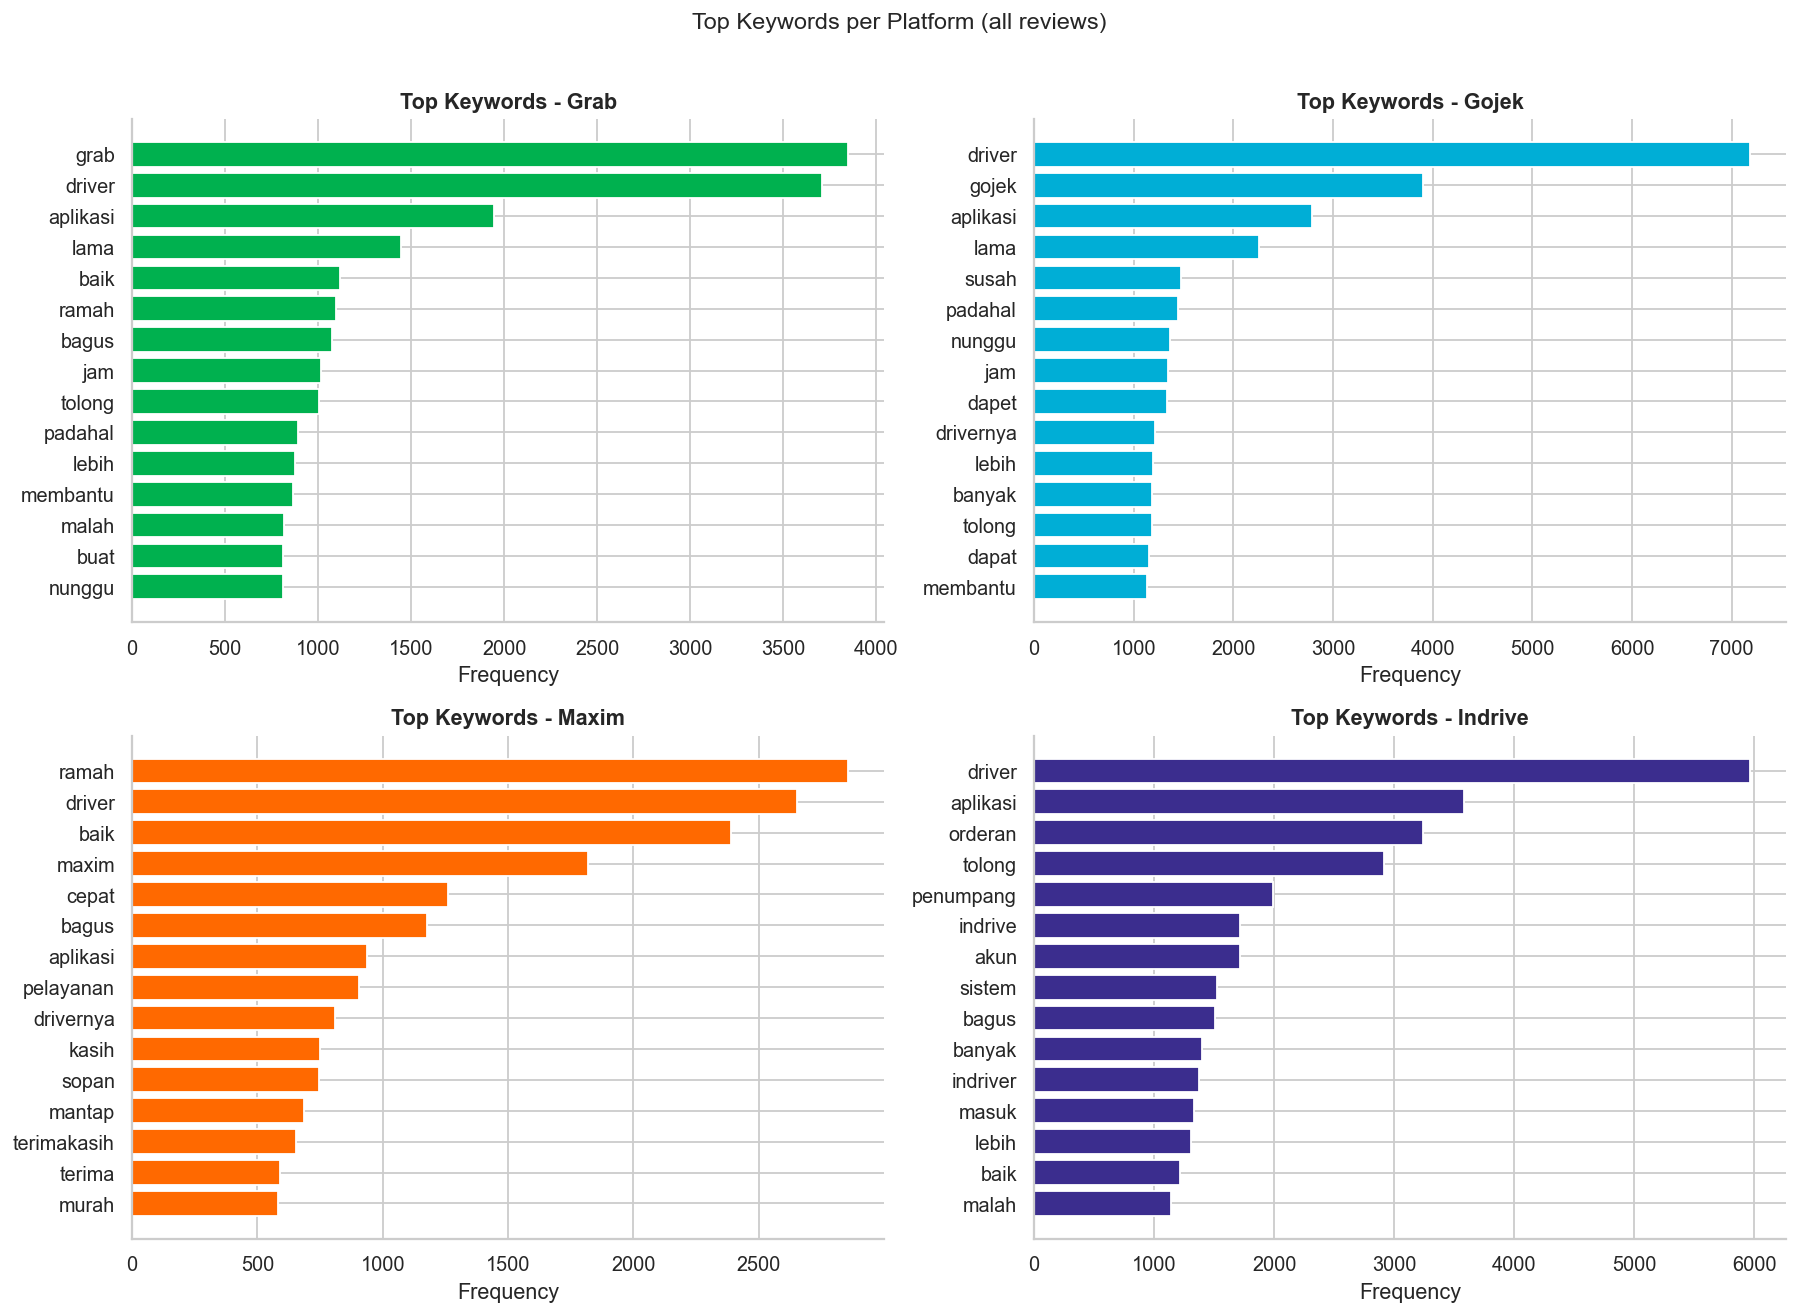

In [ ]:
# Indonesian stopwords (basic list - expand as needed)
ID_STOPWORDS = set(
    "yang dan di ke dari untuk ada tidak dengan ini itu "
    "juga sudah saya aku kamu anda kak mas mbak bisa "
    "sangat banget sekali memang kalau karena tapi tp "
    "ya udah deh nih dong emang ga gak nggak ngga "
    "nya si pun lagi aja bgt yg dgn krn udh sih "
    "belum baru lg uda bener mau gimana sama terus kan jadi "
    "habis pake pakai cuma hanya".split()
)

def top_keywords(series, n=20, stopwords=ID_STOPWORDS):
    import re
    from collections import Counter
    words = []
    for text in series.fillna(""):
        tokens = re.findall(r"[a-zA-Z]{3,}", text.lower())
        words += [w for w in tokens if w not in stopwords]
    return Counter(words).most_common(n)

# --- SAFETY NET ---
# Pastikan kolom content_normalized benar-benar ada di notebook ini
if "content_normalized" not in df.columns:
    df["content_normalized"] = df["content"].fillna("").str.lower()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, p in zip(axes, PLATFORMS):
    # FILTER SUPER AMAN: 
    # Ubah data di kolom jadi string, hapus spasi ujungnya, jadikan huruf kecil semua
    mask = df["platform"].astype(str).str.strip().str.lower() == p.lower()
    sub = df[mask]["content_normalized"]
    
    # Deteksi jika data gagal difilter
    if len(sub) == 0:
        print(f"⚠️ Peringatan: Data '{p}' kosong! Cek kembali isi kolom df['platform'].")
        ax.set_visible(False)
        continue
        
    kw = top_keywords(sub, n=15)
    
    if not kw:
        print(f"⚠️ Peringatan: Tidak ada kata yang ditemukan untuk '{p}'.")
        ax.set_visible(False)
        continue
        
    words, counts = zip(*kw)
    
    # Tambahkan .lower() pada p untuk memastikan warna terpanggil dari PALETTE
    ax.barh(list(reversed(words)), list(reversed(counts)),
            color=PALETTE.get(p.lower(), "grey"), edgecolor="white")
    ax.set_title(f"Top Keywords - {p.capitalize()}", fontweight="bold")
    ax.set_xlabel("Frequency")

plt.suptitle("Top Keywords per Platform (all reviews)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_top_keywords.png", bbox_inches="tight")
plt.show()

> * **Maxim's top keywords are overwhelmingly positive and service-oriented**, heavily featuring praise like **"ramah" (friendly), "baik" (good), "cepat" (fast)**, and **"murah" (cheap)**, which aligns directly with its top-tier satisfaction ratings.
> * **Gojek and Grab share prominent complaints regarding wait times**, with both platforms frequently triggering negative behavioral keywords like **"lama" (long/slow)** and **"nunggu" (waiting)**.
> * **Gojek's user reviews show high frustration and friction**, unique for its prominent inclusion of negative sentiment indicators and problem-focused words such as **"susah" (difficult)** and **"padahal" (even though/whereas)**.
> * **Indrive reviews are strictly transactional and system-focused**, dominated by operational keywords like **"orderan" (orders), "penumpang" (passengers)**, and **"akun" (account)** rather than emotional or service-quality descriptors.

## **8. Pain Points vs. Praise Keywords per Platform**

This cell extends the keyword analysis by splitting reviews into two sentiment buckets per platform: **Pain Points** (1–2 star reviews, shown in red) and **Praise** (5-star reviews, shown in green). The result is a grid of 4 rows × 2 columns — one row per platform, left column for complaints and right column for compliments. The same `top_keywords()` function is reused with `n=12`. Each subplot is labeled and color-coded. Defensive checks handle cases where a subset might be empty. This is one of the most actionable charts in the EDA — it reveals not just overall sentiment but the specific features users love or find frustrating on each platform.

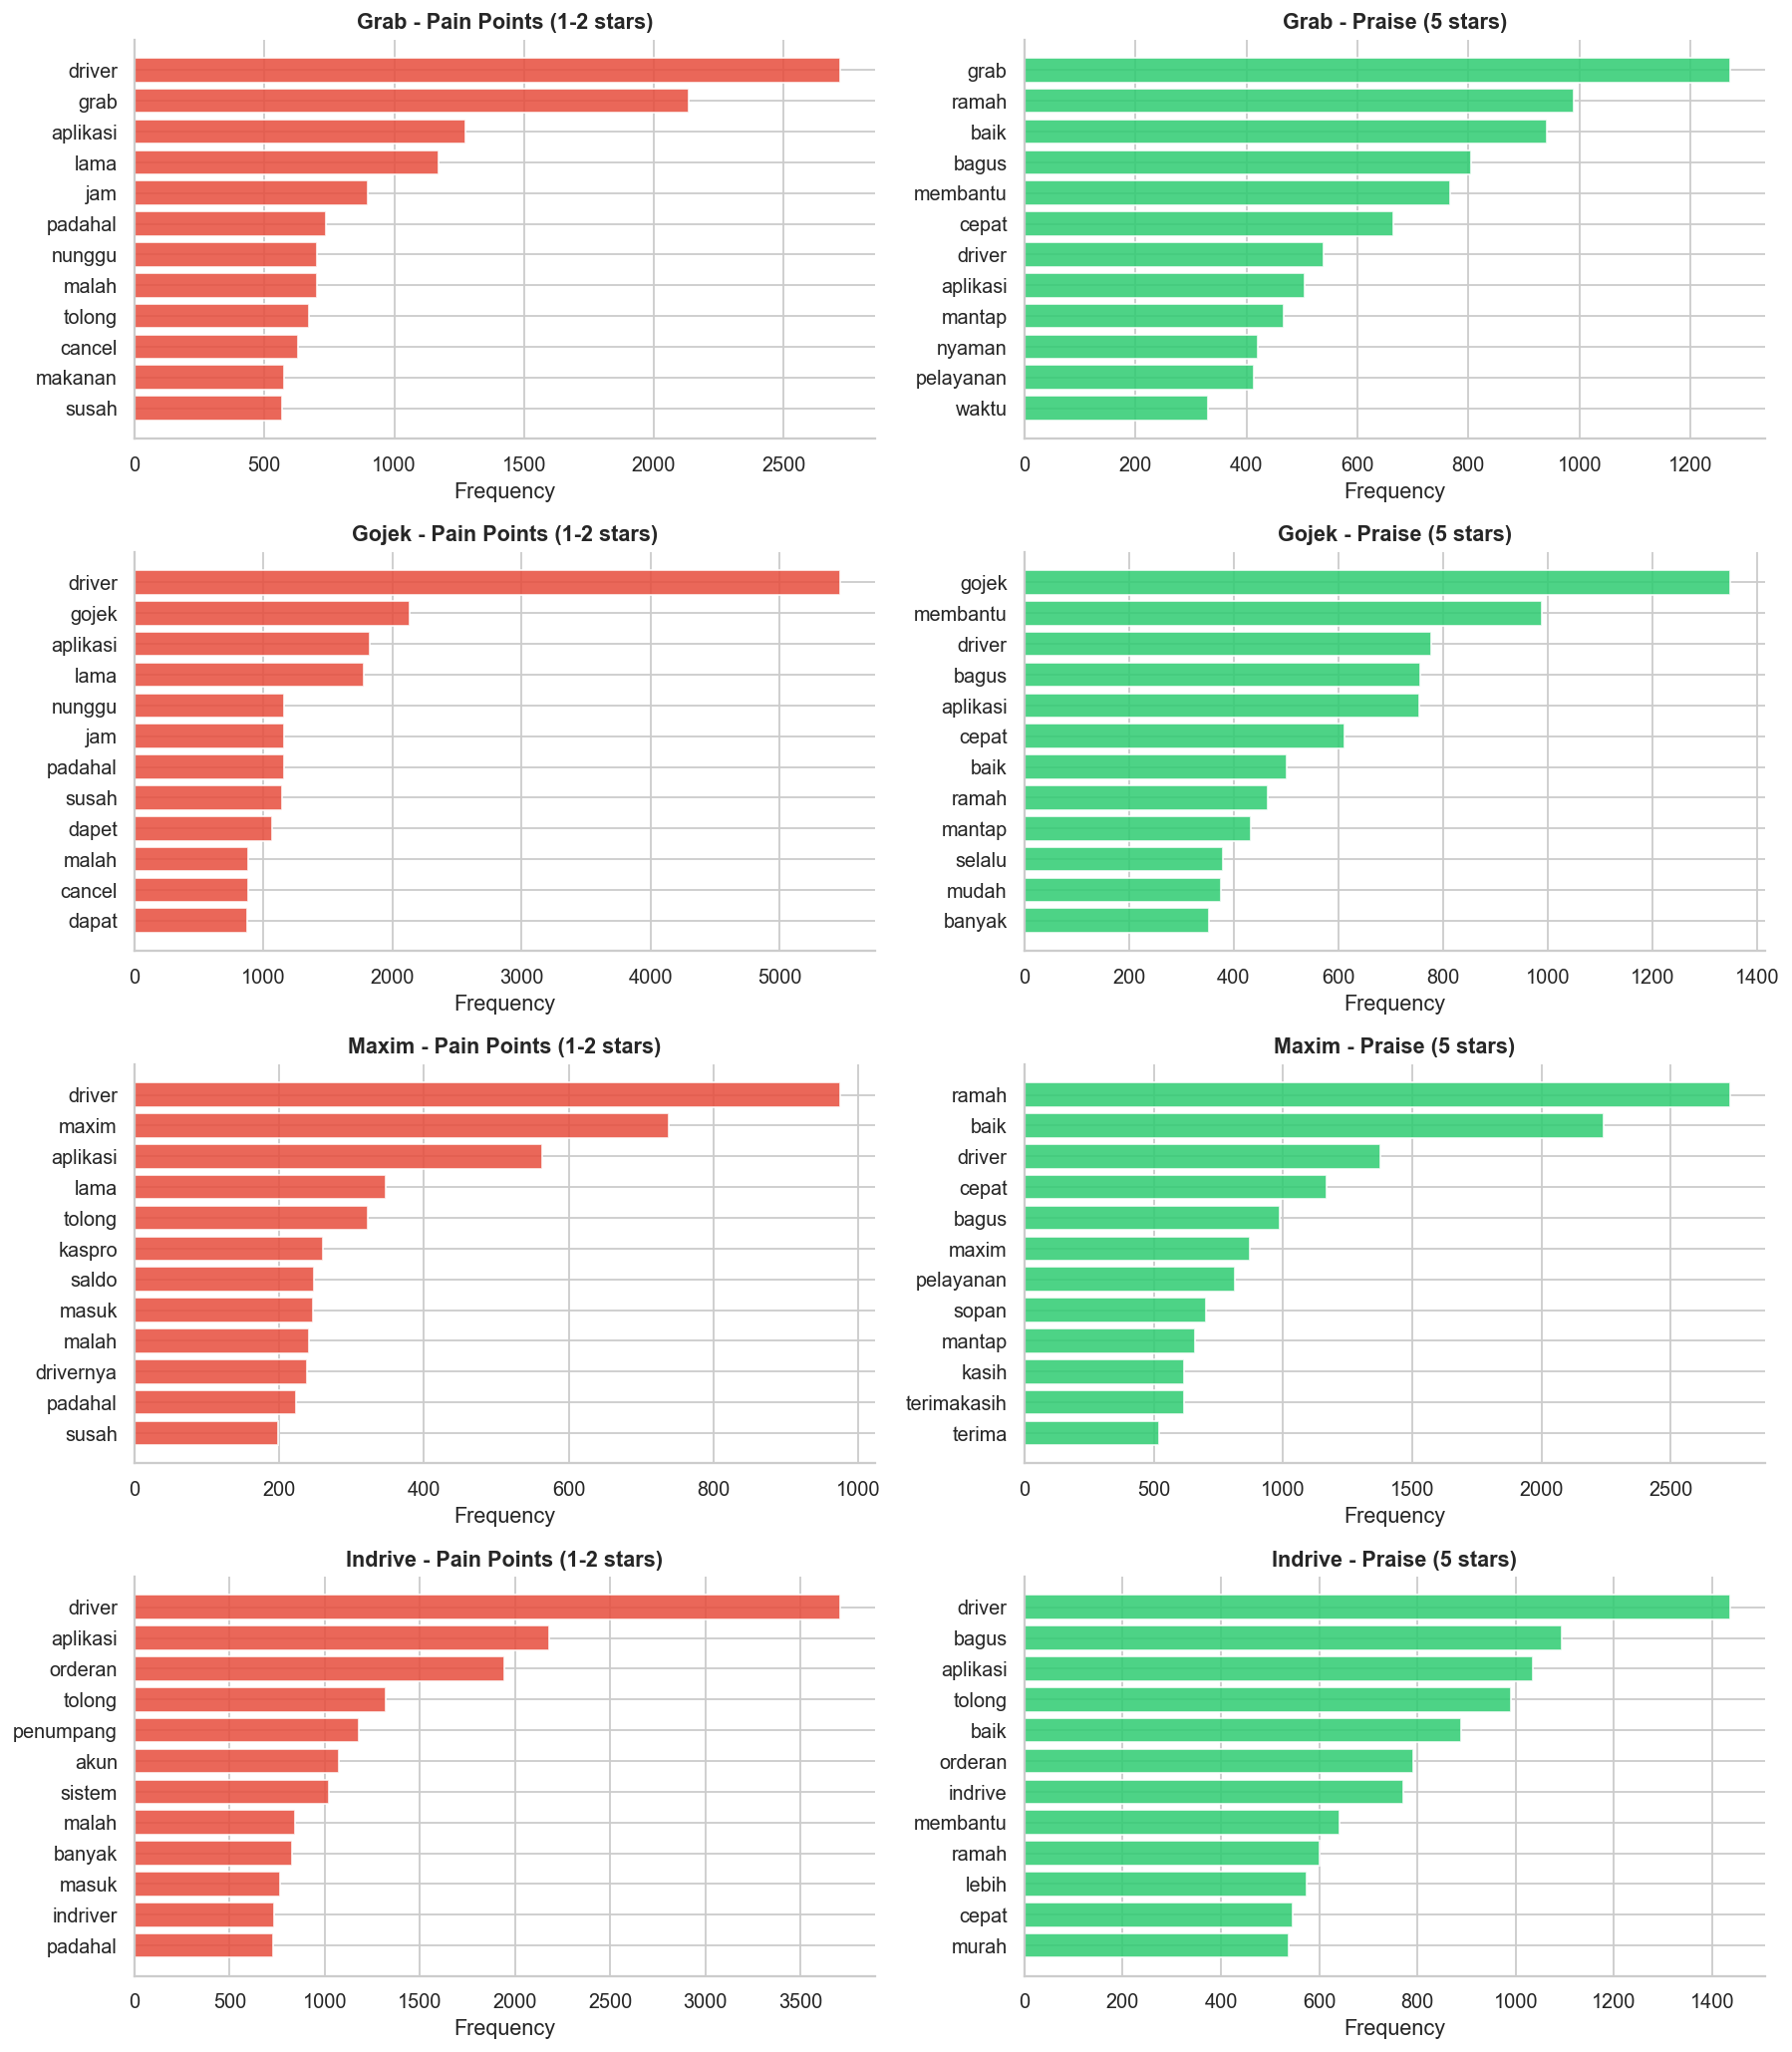

In [ ]:
fig, axes = plt.subplots(len(PLATFORMS), 2, figsize=(14, 4 * len(PLATFORMS)))

for i, p in enumerate(PLATFORMS):
    # FILTER SUPER AMAN: 
    # Ubah data di kolom jadi string, hapus spasi ujungnya, jadikan huruf kecil semua
    mask = df["platform"].astype(str).str.strip().str.lower() == p.lower()
    pdata = df[mask]
    
    neg = pdata[pdata["score"] <= 2]["content_normalized"]
    pos = pdata[pdata["score"] == 5]["content_normalized"]

    for j, (subset, label, color) in enumerate([
        (neg, "Pain Points (1-2 stars)", "#E74C3C"),
        (pos, "Praise (5 stars)", "#2ECC71")
    ]):
        ax = axes[i][j]
        
        # Deteksi jika data review-nya kosong
        if len(subset) == 0:
            print(f"⚠️ Peringatan: Data {label} untuk '{p}' kosong!")
            ax.set_title(f"{p.capitalize()} - {label} (No Data)", fontweight="bold")
            continue
            
        kw = top_keywords(subset, n=12)
        
        if kw:
            words, counts = zip(*kw)
            ax.barh(list(reversed(words)), list(reversed(counts)),
                    color=color, edgecolor="white", alpha=0.85)
            ax.set_title(f"{p.capitalize()} - {label}", fontweight="bold")
            ax.set_xlabel("Frequency")
        else:
            print(f"⚠️ Peringatan: Tidak ada kata kunci yang ditemukan untuk {label} '{p}'.")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_pain_praise.png", bbox_inches="tight") 
plt.show()

> * **"Driver" and "Aplikasi" (App) are the universal triggers for both extreme frustration and extreme praise** across all four platforms, indicating that driver behavior and app stability dictate the core user experience.
> * **Grab and Gojek share identical operational bottlenecks**, with both heavily plagued by time-related complaints such as **"lama" (long/slow)** and **"nunggu" (waiting)** in their 1–2 star reviews.
> * **Maxim excels heavily on customer service and driver attitude**, commanding immense praise with dominant keywords like **"ramah" (friendly)** and **"baik" (good)**, while its main pain points are uniquely tied to payment/wallet issues like **"kaspro"** and **"saldo"**.
> * **Indrive's feedback loop is strictly system and order-driven**, where negative reviews focus heavily on technical frictions like **"orderan" (orders)** and **"sistem" (system)** rather than general wait times.

## **9. Developer Reply Rate & Median Response Time**

This cell analyzes how responsive each platform's support team is to user reviews. It first detects the correct column names defensively (handling both `replied_at` and `repliedAt` variants). `reply_stats` aggregates the total review count and number of replied reviews per platform, then calculates the reply rate as a percentage. For replied reviews, `response_hours` is computed as the difference between `replied_at` and `at`, converted to hours and capped at 720 (30 days) to remove outliers. Two bar charts are produced side by side: the left shows **reply rate (%)** and the right shows **median response time in hours**. Key finding from the output: InDrive has the highest reply rate (56.2%) while Maxim barely replies (0.8%). If the `replied_at` column is unavailable, the right chart displays a 'N/A' message gracefully.

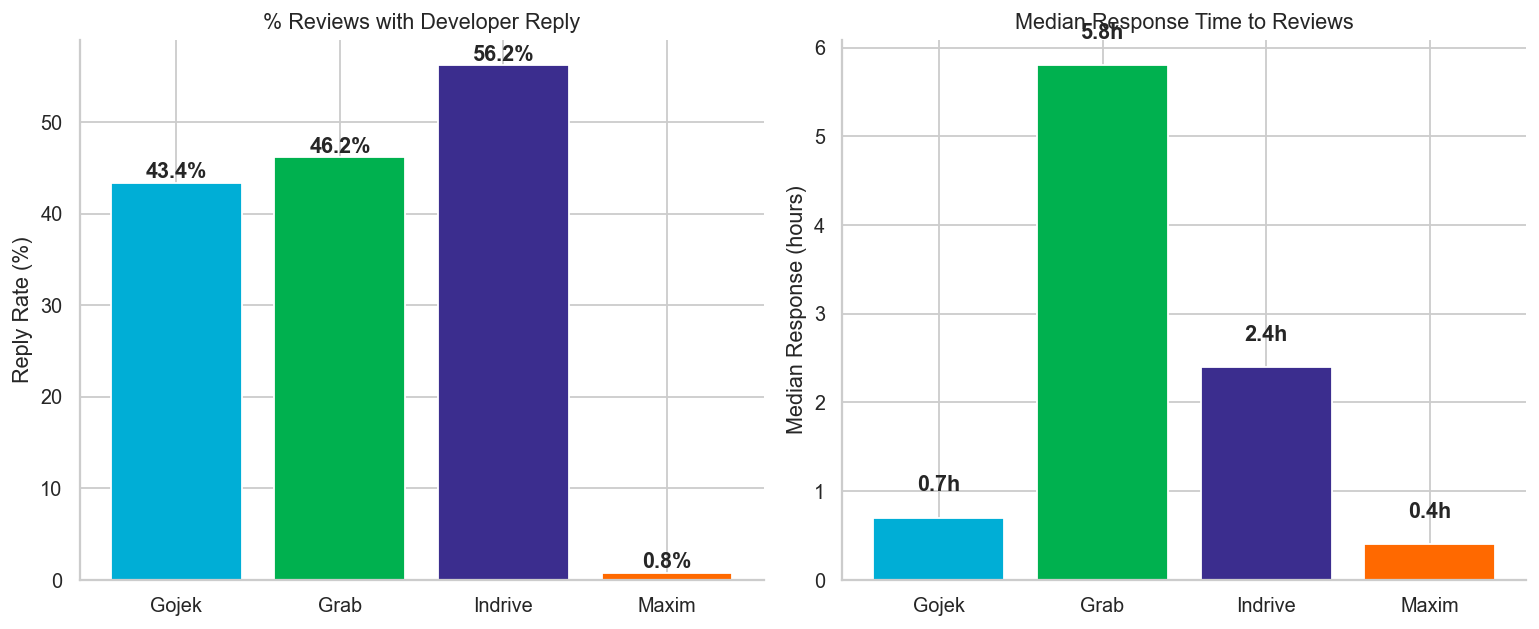

          total  replied  reply_rate
platform                            
gojek     18301     7936        43.4
grab      16218     7490        46.2
indrive   17979    10098        56.2
maxim     14380      114         0.8


In [56]:
# 1. Deteksi nama kolom yang benar agar terhindar dari salah ejaan
replied_col = "replied_at" if "replied_at" in df.columns else "repliedAt"
id_col = "review_id" if "review_id" in df.columns else "reviewId"

reply_stats = df.groupby("platform").agg(
    total=(id_col, "count"),
    replied=("has_reply", "sum"),
).assign(reply_rate=lambda x: (x["replied"] / x["total"] * 100).round(1))

df_replied = df[df["has_reply"] == 1].copy()

if replied_col in df.columns:
    # 2. PERBAIKAN: Pastikan kolom 'at' juga diubah ke datetime sebelum dikurangi
    df_replied[replied_col] = pd.to_datetime(df_replied[replied_col], errors="coerce")
    df_replied["at"] = pd.to_datetime(df_replied["at"], errors="coerce")
    
    df_replied["response_hours"] = (
        (df_replied[replied_col] - df_replied["at"]).dt.total_seconds() / 3600
    ).clip(0, 720)
    
    # Tambahkan .dropna() untuk berjaga-jaga jika ada baris kosong
    resp_speed = df_replied.groupby("platform")["response_hours"].median().round(1).dropna()
else:
    resp_speed = pd.Series(dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Grafik Kiri (Reply Rate) ---
bars = axes[0].bar(
    reply_stats.index.str.capitalize(),
    reply_stats["reply_rate"],
    color=[PALETTE.get(p.lower(), "grey") for p in reply_stats.index], edgecolor="white"
)
axes[0].set_ylabel("Reply Rate (%)")
axes[0].set_title("% Reviews with Developer Reply")
for bar, val in zip(bars, reply_stats["reply_rate"]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val}%", ha="center", fontweight="bold")

# --- Grafik Kanan (Median Response Time) ---
if not resp_speed.empty:
    bars2 = axes[1].bar(
        resp_speed.index.str.capitalize(),
        resp_speed.values,
        # Warna sudah ditambahkan .lower() agar tidak abu-abu
        color=[PALETTE.get(p.lower(), "grey") for p in resp_speed.index], 
        edgecolor="white"
    )
    axes[1].set_ylabel("Median Response (hours)")
    axes[1].set_title("Median Response Time to Reviews")
    for bar, val in zip(bars2, resp_speed.values):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f"{val}h", ha="center", fontweight="bold")
else:
    axes[1].text(0.5, 0.5, f"No '{replied_col}' data available",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("Response Time (N/A)")

plt.tight_layout()
# plt.savefig(FIG_DIR / "04_reply_stats.png", bbox_inches="tight") # Uncomment jika ingin disimpan
plt.show()
print(reply_stats)

> * **Indrive is the most active in engaging with users**, boasting the highest developer reply rate at **56.2%**, followed closely by Grab (**46.2%**) and Gojek (**43.4%**).
> * **Maxim completely neglects review engagement**, leaving a staggering majority of its user feedback unanswered with a reply rate of **just 0.8%**.
> * **Gojek strikes the best balance between diligence and speed**, maintaining a high reply rate while responding remarkably fast with a median time of **only 0.7 hours**.
> * **Grab struggles significantly with operational responsiveness**, taking an exceptionally long median time of **5.8 hours** to reply to reviews despite answering nearly half of them.

## **10. Churn Risk Signal Detection**

This cell implements a keyword-based churn risk proxy. A list of Indonesian churn-intent keywords (`CHURN_KEYWORDS`) is defined, covering explicit uninstall intent (`uninstall`, `hapus`, `delete`), switching signals (`pindah`, `ganti`, `beralih`, `switch`), and expressions of giving up (`kapok`, `bye`, `selamat tinggal`, `pakai aplikasi lain`). The function `has_churn_signal()` checks if any keyword appears in a lowercased review and returns 1 or 0. This flag is applied to all rows as a new column `churn_signal`. A grouped summary is printed showing absolute churn counts and rates per platform. A bar chart visualizes the churn rate percentage per platform, with value labels on top. Key finding: Gojek has the highest churn signal rate (5.65%), while Maxim has the lowest (1.77%). Saved as `04_churn_signal.png`.

          total  churn  churn_rate_pct
platform                              
gojek     18301   1034            5.65
grab      16218    722            4.45
indrive   17979    934            5.19
maxim     14380    255            1.77


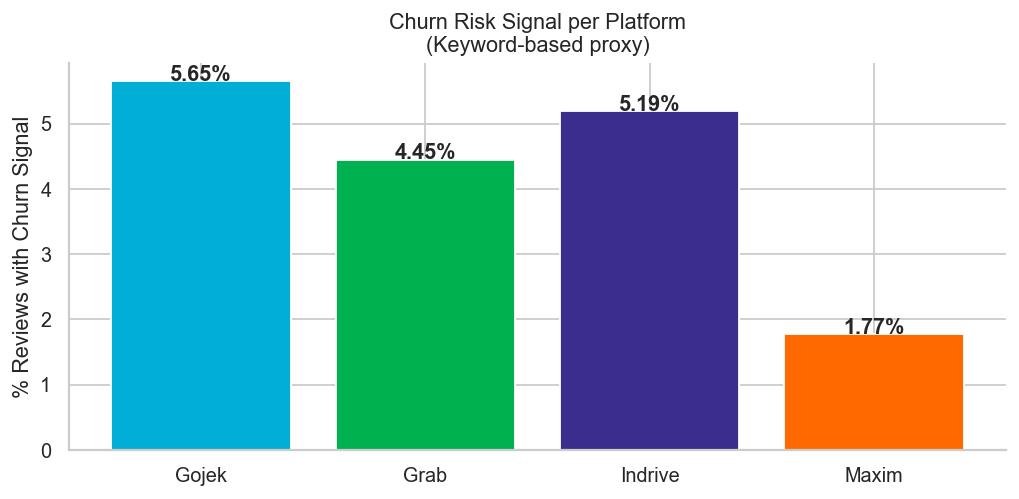

In [57]:
CHURN_KEYWORDS = [
    "pindah", "uninstall", "hapus", "berhenti", "ganti",
    "switch", "delete", "tidak mau", "kapok", "beralih",
    "lebih baik", "lebih bagus", "mending", "cobain yang lain",
    "bye", "selamat tinggal", "pakai aplikasi lain"
]

def has_churn_signal(text):
    if not isinstance(text, str): return 0
    t = text.lower()
    return int(any(kw in t for kw in CHURN_KEYWORDS))

df["churn_signal"] = df["content_normalized"].apply(has_churn_signal)

churn_rate = df.groupby("platform").agg(
    total=("churn_signal","count"),
    churn=("churn_signal","sum")
).assign(churn_rate_pct=lambda x: (x["churn"]/x["total"]*100).round(2))
print(churn_rate)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    churn_rate.index.str.capitalize(),
    churn_rate["churn_rate_pct"],
    color=[PALETTE[p.lower()] for p in churn_rate.index], edgecolor="white"
)
ax.set_ylabel("% Reviews with Churn Signal")
ax.set_title("Churn Risk Signal per Platform\n(Keyword-based proxy)")
for bar, val in zip(bars, churn_rate["churn_rate_pct"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_churn_signal.png", bbox_inches="tight")
plt.show()


> * **Gojek faces the highest customer attrition risk**, leading the chart with **5.65%** of its reviews triggering churn risk signals.
> * **Indrive also exhibits a high vulnerability to user loss**, following closely behind Gojek with a **5.19%** churn signal rate.
> * **Maxim demonstrates exceptional user retention strength**, maintaining a significantly lower churn risk profile at **only 1.77%**, which is less than half of any competitor's rate.